# Goals

- Classify stress from voice:
    - Neutral
    - Medium stress
    - High stress

# Steps to the first experiment

1. Data collection
    - Import data
    - Explore speech data
2. Prepare for training:
    - Feature extraction

3. Train (either from scratch or transfer learning)

4. Evaluate model

In [1]:
%%capture

!pip install git+https://github.com/huggingface/datasets.git
!pip install git+https://github.com/huggingface/transformers.git
!pip install jiwer
!pip install torchaudio
!pip install librosa
!pip install evaluate

In [2]:
%%capture
!pip install -U "transformers>=4.40.0" "accelerate>=0.29.0" "datasets==2.16.1" "evaluate==0.4.0" "peft==0.9.0"

In [3]:
%env LC_ALL=C.UTF-8
%env LANG=C.UTF-8
%env TRANSFORMERS_CACHE=/content/cache
%env HF_DATASETS_CACHE=/content/cache
%env CUDA_LAUNCH_BLOCKING=1 # Forces GPU operations (CUDA) to run synchronously instead of asynchronously.

env: LC_ALL=C.UTF-8
env: LANG=C.UTF-8
env: TRANSFORMERS_CACHE=/content/cache
env: HF_DATASETS_CACHE=/content/cache
env: CUDA_LAUNCH_BLOCKING=1 # Forces GPU operations (CUDA) to run synchronously instead of asynchronously.


In [4]:
# This part is just for trying out Weights and Biases for model training and tracking of different metrics

%env WANDB_WATCH=all
%env WANDB_LOG_MODEL=1
%env WANDB_PROJECT=YOUR_PROJECT_NAME
!wandb login 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 --relogin

env: WANDB_WATCH=all
env: WANDB_LOG_MODEL=1
env: WANDB_PROJECT=YOUR_PROJECT_NAME
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


# Downloading the Data
- The data is emotion based from [Acted Emotional Speech Dynamic Database – AESDD](http://m3c.web.auth.gr/research/aesdd-speech-emotion-recognition/)
  - The Acted Emotional Speech Dynamic Database (AESDD) is a publically available speech emotion recognition dataset that contains utterances of acted emotional speech in the Greek language for five different emotions `sadness`, `disgust`, `happiness`, `anger`, and `fear`.

In [6]:
# Download the dataset from

!mkdir -p /content/data
!gdown https://drive.google.com/uc?id=1_IAWexEWpH-ly_JaA5EGfZDp-_3flkN1
!unzip -q aesdd.zip -d /content/data/
!mv "/content/data/Acted Emotional Speech Dynamic Database/" /content/data/aesdd/

Downloading...
From (original): https://drive.google.com/uc?id=1_IAWexEWpH-ly_JaA5EGfZDp-_3flkN1
From (redirected): https://drive.google.com/uc?id=1_IAWexEWpH-ly_JaA5EGfZDp-_3flkN1&confirm=t&uuid=6042f3c3-7cea-4475-a0be-bd1cbff70d86
To: /content/aesdd.zip
100% 410M/410M [00:02<00:00, 164MB/s]
replace /content/data/Acted Emotional Speech Dynamic Database/fear/f18 (6).wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
mv: cannot move '/content/data/Acted Emotional Speech Dynamic Database/' to '/content/data/aesdd/Acted Emotional Speech Dynamic Database': Directory not empty


In [7]:
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import torchaudio
from sklearn.model_selection import train_test_split

import os
import sys

In [8]:
data = []

for path in tqdm(Path("/content/data/aesdd").glob("**/*.wav")):
    name = str(path).split('/')[-1].split('.')[0]
    label = str(path).split('/')[-2]

    try:
        # There are some broken files
        s = torchaudio.load(path)
        data.append({
            "name": name,
            "path": path,
            "emotion": label
        })
    except Exception as e:
        # print(str(path), e)
        pass

    # break

1210it [00:06, 173.84it/s]


In [11]:
df = pd.DataFrame(data)
df.head()

,name,path,emotion
0,d16 (3),/content/data/aesdd/disgust/d16 (3).wav,disgust
1,d16 (6),/content/data/aesdd/disgust/d16 (6).wav,disgust
2,d14 (4),/content/data/aesdd/disgust/d14 (4).wav,disgust
3,d06 (3),/content/data/aesdd/disgust/d06 (3).wav,disgust
4,d02 (2),/content/data/aesdd/disgust/d02 (2).wav,disgust


In [14]:
# Filter broken and non-existed paths

print(f"Step 0: {len(df)}")

df["status"] = df["path"].apply(lambda path: True if os.path.exists(path) else None)
df = df.dropna(subset=["path"])
df = df.drop("status", axis=1)
print(f"Step 1: {len(df)}")

df = df.sample(frac=1)
df = df.reset_index(drop=True)
df.head()

Step 0: 1208
Step 1: 1208


,name,path,emotion
0,h09 (4),/content/data/aesdd/happiness/h09 (4).wav,happiness
1,f15 (3),/content/data/aesdd/Acted Emotional Speech Dyn...,fear
2,a09 (5),/content/data/aesdd/anger/a09 (5).wav,anger
3,f10 (6),/content/data/aesdd/fear/f10 (6).wav,fear
4,a13 (2),/content/data/aesdd/anger/a13 (2).wav,anger


# Lets check what labels we have
- We want to map the emotion labels to stress levels...

In [15]:
print("Labels: ", df["emotion"].unique())
print()
df.groupby("emotion").count()[["path"]]

Labels:  ['happiness' 'fear' 'anger' 'sadness' 'disgust']



,path
emotion,
anger,242
disgust,244
fear,240
happiness,238
sadness,244


### Lövheims cube of emotions for mapping emotions to stress levels

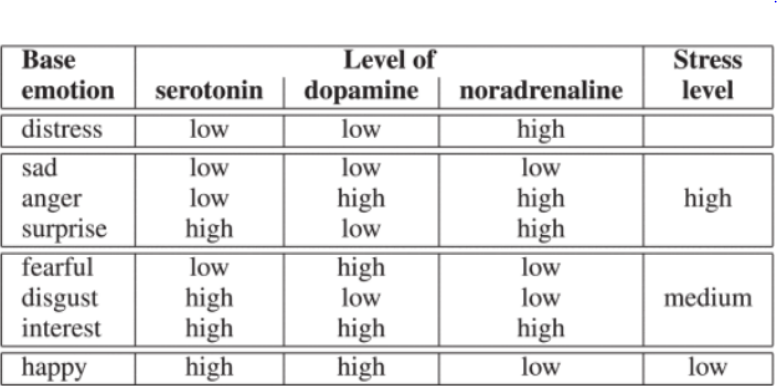

In [16]:
stress_mapping = {
    "happiness": "low",
    "sadness":   "high",
    "disgust":   "medium",
    "anger":     "high",
    "fear":      "medium",
}

df["stress_level"] = df["emotion"].map(stress_mapping)

print("Labels: ", df["stress_level"].unique())
print()
df.groupby("stress_level").count()[["path"]]

Labels:  ['low' 'medium' 'high']



,path
stress_level,
high,486
low,238
medium,484


In [17]:
df = df.drop("emotion", axis=1)

# Just gonna try undersampling first

In [55]:
df = df.groupby("stress_level").sample(n=238, random_state=42)
df.groupby("stress_level").count()[["path"]]

,path
stress_level,
high,238
low,238
medium,238


For training purposes, we need to split data into train test sets

In [19]:
save_path = "/content/data"

train_df, test_df = train_test_split(df, test_size=0.2, random_state=101, stratify=df["stress_level"])

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(f"{save_path}/train.csv", sep="\t", encoding="utf-8", index=False)
test_df.to_csv(f"{save_path}/test.csv", sep="\t", encoding="utf-8", index=False)


print(train_df.shape)
print(test_df.shape)

(966, 3)
(242, 3)


## Prepare Data for Training

In [20]:
from datasets import load_dataset
import evaluate

data_files = {
    "train": "/content/data/train.csv",
    "validation": "/content/data/test.csv",
}

dataset = load_dataset("csv", data_files=data_files, delimiter="\t")
train_dataset = dataset["train"]
eval_dataset = dataset["validation"]

print(train_dataset)
print(eval_dataset)

Generating train split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/download/streaming_download_manager.py:778: FutureWarning: The 'verbose' keyword in pd.read_csv is deprecated and will be removed in a future version.
  return pd.read_csv(xopen(filepath_or_buffer, "rb", download_config=download_config), **kwargs)


Generating validation split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['name', 'path', 'stress_level'],
    num_rows: 966
})
Dataset({
    features: ['name', 'path', 'stress_level'],
    num_rows: 242
})


/usr/local/lib/python3.12/dist-packages/datasets/download/streaming_download_manager.py:778: FutureWarning: The 'verbose' keyword in pd.read_csv is deprecated and will be removed in a future version.
  return pd.read_csv(xopen(filepath_or_buffer, "rb", download_config=download_config), **kwargs)


In [21]:
# We need to specify the input and output column
input_column = "path"
output_column = "stress_level"

In [22]:
# we need to distinguish the unique labels in our SER dataset
label_list = train_dataset.unique(output_column)
label_list.sort()  # Let's sort it for determinism
num_labels = len(label_list)
print(f"A classification problem with {num_labels} classes: {label_list}")

A classification problem with 3 classes: ['high', 'low', 'medium']


In order to preprocess the audio into our classification model, we need to set up the relevant Wav2Vec2 assets regarding our multilingual use case using `facebook/wav2vec2-xls-r-300m`, a large cross-lingual speech representation model pretrained on 53 languages including English and Swedish [link to huggingface](https://huggingface.co/facebook/wav2vec2-xls-r-300m). Since stress and emotion patterns such as tone, pitch, and rhythm are largely language-agnostic, this model is well suited for cross-lingual stress level classification. To handle the context representations in any audio length we use a merge strategy plan (pooling mode) to concatenate the 3D representations into 2D representations.

In [23]:
from transformers import AutoConfig, Wav2Vec2Processor

### About the model:


- When using the model make sure that your speech input is sampled at 16kHz

In [24]:
model_name_or_path = "facebook/wav2vec2-xls-r-300m"
pooling_mode = "mean"

In [25]:
# config
config = AutoConfig.from_pretrained(
    model_name_or_path,
    num_labels=num_labels,
    label2id={label: i for i, label in enumerate(label_list)},
    id2label={i: label for i, label in enumerate(label_list)},
    finetuning_task="wav2vec2_clf",
)
setattr(config, 'pooling_mode', pooling_mode)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [26]:
from transformers import Wav2Vec2FeatureExtractor
import torchaudio

# Use FeatureExtractor instead of Processor to avoid vocabulary dependency
processor = Wav2Vec2FeatureExtractor.from_pretrained(model_name_or_path)
target_sampling_rate = processor.sampling_rate
print(f"The target sampling rate: {target_sampling_rate}")

The target sampling rate: 16000


# Preprocess Data

Now, we need to extract features from the audio path in context representation tensors and feed them into our classification model to determine the stress in the speech.

In [27]:
def speech_file_to_array_fn(path):
    speech_array, sampling_rate = torchaudio.load(path)
    resampler = torchaudio.transforms.Resample(sampling_rate, target_sampling_rate)
    speech = resampler(speech_array).squeeze().numpy()
    return speech

def label_to_id(label, label_list):

    if len(label_list) > 0:
        return label_list.index(label) if label in label_list else -1

    return label

def preprocess_function(examples):
    speech_list = [speech_file_to_array_fn(path) for path in examples[input_column]]
    target_list = [label_to_id(label, label_list) for label in examples[output_column]]

    result = processor(speech_list, sampling_rate=target_sampling_rate)
    result["labels"] = list(target_list)

    return result

In [28]:
train_dataset = train_dataset.map(
    preprocess_function,
    batch_size=100,
    batched=True,
    num_proc=4
)
eval_dataset = eval_dataset.map(
    preprocess_function,
    batch_size=100,
    batched=True,
    num_proc=4
)

Map (num_proc=4):   0%|          | 0/966 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/242 [00:00<?, ? examples/s]

In [29]:
idx = 0
print(f"Training input_values: {train_dataset[idx]['input_values']}")
print(f"Training attention_mask: {train_dataset[idx]['attention_mask']}")
print(f"Training labels: {train_dataset[idx]['labels']} - {train_dataset[idx]['stress_level']}")

Training input_values: [-0.007420807611197233, -0.005111221224069595, -0.004875634331256151, -0.010746393352746964, -0.0058173383586108685, 0.0013403508346527815, 0.0015249985735863447, 0.0032321137841790915, 0.008976037614047527, 0.01537290122359991, 0.020961130037903786, 0.018546003848314285, 0.011735647916793823, 0.014469286426901817, 0.023430559784173965, 0.02625051885843277, 0.02064741589128971, 0.011637922376394272, 0.007576844654977322, 0.008817403577268124, 0.009904714301228523, 0.006906562484800816, 0.004750682506710291, 0.0036234597209841013, -0.0033286886755377054, -0.0041709644719958305, 0.0011971252970397472, -0.002905474044382572, -0.012705721892416477, -0.013408442959189415, -0.00616129394620657, -0.005221433471888304, -0.011935177259147167, -0.015924543142318726, -0.014989669434726238, -0.01462893933057785, -0.015348708257079124, -0.012666403315961361, -0.005162290297448635, -0.004076795652508736, -0.010210737586021423, -0.010458389297127724, -0.005394803360104561, 2.21

# Model

Before diving into the training part, we need to build our classification model based on the merge strategy.

In [30]:
from dataclasses import dataclass
from typing import Optional, Tuple
import torch
from transformers.file_utils import ModelOutput


@dataclass
class SpeechClassifierOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None
    hidden_states: Optional[Tuple[torch.FloatTensor]] = None
    attentions: Optional[Tuple[torch.FloatTensor]] = None

In [31]:
import torch
import torch.nn as nn
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss, MSELoss

from transformers.models.wav2vec2.modeling_wav2vec2 import (
    Wav2Vec2PreTrainedModel,
    Wav2Vec2Model
)


class Wav2Vec2ClassificationHead(nn.Module):
    """Head for wav2vec classification task."""

    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.final_dropout)
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, features, **kwargs):
        x = features
        x = self.dropout(x)
        x = self.dense(x)
        x = torch.tanh(x)
        x = self.dropout(x)
        x = self.out_proj(x)
        return x


class Wav2Vec2ForSpeechClassification(Wav2Vec2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.pooling_mode = config.pooling_mode
        self.config = config

        self.wav2vec2 = Wav2Vec2Model(config)
        self.classifier = Wav2Vec2ClassificationHead(config)

        self.post_init()  # <-- changed from self.init_weights()

    def freeze_feature_extractor(self):
        self.wav2vec2.feature_extractor._freeze_parameters()

    def merged_strategy(
            self,
            hidden_states,
            mode="mean"
    ):
        if mode == "mean":
            outputs = torch.mean(hidden_states, dim=1)
        elif mode == "sum":
            outputs = torch.sum(hidden_states, dim=1)
        elif mode == "max":
            outputs = torch.max(hidden_states, dim=1)[0]
        else:
            raise Exception(
                "The pooling method hasn't been defined! Your pooling mode must be one of these ['mean', 'sum', 'max']")

        return outputs

    def forward(
            self,
            input_values,
            attention_mask=None,
            output_attentions=None,
            output_hidden_states=None,
            return_dict=None,
            labels=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs = self.wav2vec2(
            input_values,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        hidden_states = outputs[0]
        hidden_states = self.merged_strategy(hidden_states, mode=self.pooling_mode)
        logits = self.classifier(hidden_states)

        loss = None
        if labels is not None:
            if self.config.problem_type is None:
                if self.num_labels == 1:
                    self.config.problem_type = "regression"
                elif self.num_labels > 1 and (labels.dtype == torch.long or labels.dtype == torch.int):
                    self.config.problem_type = "single_label_classification"
                else:
                    self.config.problem_type = "multi_label_classification"

            if self.config.problem_type == "regression":
                loss_fct = MSELoss()
                loss = loss_fct(logits.view(-1, self.num_labels), labels)
            elif self.config.problem_type == "single_label_classification":
                loss_fct = CrossEntropyLoss()
                loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            elif self.config.problem_type == "multi_label_classification":
                loss_fct = BCEWithLogitsLoss()
                loss = loss_fct(logits, labels)

        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return SpeechClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

In [32]:
from dataclasses import dataclass
from typing import Dict, List, Optional, Union
import torch

import transformers
from transformers import Wav2Vec2Processor


@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    Args:
        processor (:class:`~transformers.Wav2Vec2Processor`)
            The processor used for proccessing the data.
        padding (:obj:`bool`, :obj:`str` or :class:`~transformers.tokenization_utils_base.PaddingStrategy`, `optional`, defaults to :obj:`True`):
            Select a strategy to pad the returned sequences (according to the model's padding side and padding index)
            among:
            * :obj:`True` or :obj:`'longest'`: Pad to the longest sequence in the batch (or no padding if only a single
              sequence if provided).
            * :obj:`'max_length'`: Pad to a maximum length specified with the argument :obj:`max_length` or to the
              maximum acceptable input length for the model if that argument is not provided.
            * :obj:`False` or :obj:`'do_not_pad'` (default): No padding (i.e., can output a batch with sequences of
              different lengths).
        max_length (:obj:`int`, `optional`):
            Maximum length of the ``input_values`` of the returned list and optionally padding length (see above).
        max_length_labels (:obj:`int`, `optional`):
            Maximum length of the ``labels`` returned list and optionally padding length (see above).
        pad_to_multiple_of (:obj:`int`, `optional`):
            If set will pad the sequence to a multiple of the provided value.
            This is especially useful to enable the use of Tensor Cores on NVIDIA hardware with compute capability >=
            7.5 (Volta).
    """

    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    max_length_labels: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    pad_to_multiple_of_labels: Optional[int] = None

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [feature["labels"] for feature in features]

        d_type = torch.long if isinstance(label_features[0], int) else torch.float

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        batch["labels"] = torch.tensor(label_features, dtype=d_type)

        return batch

In [33]:
from dataclasses import dataclass
from typing import Dict, List, Optional, Union
import torch

import transformers
from transformers import Wav2Vec2Processor


@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    Args:
        processor (:class:`~transformers.Wav2Vec2Processor`)
            The processor used for proccessing the data.
        padding (:obj:`bool`, :obj:`str` or :class:`~transformers.tokenization_utils_base.PaddingStrategy`, `optional`, defaults to :obj:`True`):
            Select a strategy to pad the returned sequences (according to the model's padding side and padding index)
            among:
            * :obj:`True` or :obj:`'longest'`: Pad to the longest sequence in the batch (or no padding if only a single
              sequence if provided).
            * :obj:`'max_length'`: Pad to a maximum length specified with the argument :obj:`max_length` or to the
              maximum acceptable input length for the model if that argument is not provided.
            * :obj:`False` or :obj:`'do_not_pad'` (default): No padding (i.e., can output a batch with sequences of
              different lengths).
        max_length (:obj:`int`, `optional`):
            Maximum length of the ``input_values`` of the returned list and optionally padding length (see above).
        max_length_labels (:obj:`int`, `optional`):
            Maximum length of the ``labels`` returned list and optionally padding length (see above).
        pad_to_multiple_of (:obj:`int`, `optional`):
            If set will pad the sequence to a multiple of the provided value.
            This is especially useful to enable the use of Tensor Cores on NVIDIA hardware with compute capability >=
            7.5 (Volta).
    """

    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    max_length_labels: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    pad_to_multiple_of_labels: Optional[int] = None

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [feature["labels"] for feature in features]

        d_type = torch.long if isinstance(label_features[0], int) else torch.float

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        batch["labels"] = torch.tensor(label_features, dtype=d_type)

        return batch

In [34]:
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

In [35]:
is_regression = False

In [36]:
import numpy as np
from transformers import EvalPrediction


def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    preds = np.squeeze(preds) if is_regression else np.argmax(preds, axis=1)

    if is_regression:
        return {"mse": ((preds - p.label_ids) ** 2).mean().item()}
    else:
        return {"accuracy": (preds == p.label_ids).astype(np.float32).mean().item()}

In [37]:
model = Wav2Vec2ForSpeechClassification.from_pretrained(
    model_name_or_path,
    config=config,
)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSpeechClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
classifier.dense.weight      | MISSING    | 
classifier.out_proj.weight   | MISSING    | 
classifier.dense.bias        | MISSING    | 
classifier.out_proj.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


The first component of XLSR-Wav2Vec2 consists of a stack of CNN layers that are used to extract acoustically meaningful - but contextually independent - features from the raw speech signal. This part of the model has already been sufficiently trained during pretraining and as stated in the [paper](https://arxiv.org/pdf/2006.13979.pdf) does not need to be fine-tuned anymore.
Thus, we can set the `requires_grad` to `False` for all parameters of the *feature extraction* part.

In [38]:
model.freeze_feature_extractor()

In a final step, we define all parameters related to training.
To give more explanation on some of the parameters:
- `learning_rate` and `weight_decay` were heuristically tuned until fine-tuning has become stable. Note that those parameters strongly depend on the Common Voice dataset and might be suboptimal for other speech datasets.

For more explanations on other parameters, one can take a look at the [docs](https://huggingface.co/transformers/master/main_classes/trainer.html?highlight=trainer#trainingarguments).

**Note**: If one wants to save the trained models in his/her google drive the commented-out `output_dir` can be used instead.

In [39]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/wav2vec2-xlsr-300m-stress-classification",
    # output_dir="/content/gdrive/MyDrive/wav2vec2-xlsr-greek-speech-emotion-recognition"
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    eval_strategy="steps",  # <-- changed from evaluation_strategy,
    num_train_epochs=1.0,
    fp16=True,
    save_steps=10,
    eval_steps=10,
    logging_steps=10,
    learning_rate=1e-4,
    save_total_limit=2,
)

In [40]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=processor,  # <-- changed from tokenizer
)

In [41]:
print(config.label2id)  # should show {'high': 0, 'low': 1, 'medium': 2}
print(config.id2label)  # should show {0: 'high', 1: 'low', 2: 'medium'}

{'high': 0, 'low': 1, 'medium': 2}
{0: 'high', 1: 'low', 2: 'medium'}


In [42]:
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss,Accuracy
10,1.027728,1.108957,0.400826
20,1.028583,1.066669,0.400826
30,1.030585,1.048126,0.409091
40,1.057599,1.043655,0.400826
50,1.096472,1.047478,0.400826
60,1.056030,1.030544,0.533058
70,1.062555,1.002167,0.553719
80,1.012930,0.938544,0.599174
90,0.887408,0.905233,0.574380
100,0.898181,0.969633,0.520661


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=121, training_loss=1.0172505024050877, metrics={'train_runtime': 1752.8508, 'train_samples_per_second': 0.551, 'train_steps_per_second': 0.069, 'total_flos': 1.7673208647850803e+17, 'train_loss': 1.0172505024050877, 'epoch': 1.0})

In [43]:
import librosa
from sklearn.metrics import classification_report

In [44]:
test_dataset = load_dataset("csv", data_files={"test": "/content/data/test.csv"}, delimiter="\t")["test"]
test_dataset

Generating test split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/download/streaming_download_manager.py:778: FutureWarning: The 'verbose' keyword in pd.read_csv is deprecated and will be removed in a future version.
  return pd.read_csv(xopen(filepath_or_buffer, "rb", download_config=download_config), **kwargs)


Dataset({
    features: ['name', 'path', 'stress_level'],
    num_rows: 242
})

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [46]:
def speech_file_to_array_fn(batch):
    speech_array, sampling_rate = torchaudio.load(batch["path"])
    speech_array = speech_array.squeeze().numpy()
    speech_array = librosa.resample(np.asarray(speech_array), orig_sr=sampling_rate, target_sr=processor.sampling_rate)

    batch["speech"] = speech_array
    return batch


def predict(batch):
    features = processor(batch["speech"], sampling_rate=processor.sampling_rate, return_tensors="pt", padding=True)

    input_values = features.input_values.to(device)
    attention_mask = features.attention_mask.to(device)

    with torch.no_grad():
        logits = model(input_values, attention_mask=attention_mask).logits

    pred_ids = torch.argmax(logits, dim=-1).detach().cpu().numpy()
    batch["predicted"] = pred_ids
    return batch

In [47]:
test_dataset = test_dataset.map(speech_file_to_array_fn)

Map:   0%|          | 0/242 [00:00<?, ? examples/s]

In [48]:
result = test_dataset.map(predict, batched=True, batch_size=8)

Parameter 'function'=<function predict at 0x7d046821fb00> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/242 [00:00<?, ? examples/s]

In [49]:
label_names = [config.id2label[i] for i in range(config.num_labels)]
label_names

['high', 'low', 'medium']

In [50]:
y_true = [config.label2id[name] for name in result["stress_level"]]
y_pred = result["predicted"]

print(y_true[:5])
print(y_pred[:5])

[0, 1, 0, 2, 0]
[0, 2, 2, 2, 2]


In [51]:
print(classification_report(y_true, y_pred, target_names=label_names))

              precision    recall  f1-score   support

        high       0.85      0.60      0.70        97
         low       0.00      0.00      0.00        48
      medium       0.52      0.94      0.67        97

    accuracy                           0.62       242
   macro avg       0.46      0.51      0.46       242
weighted avg       0.55      0.62      0.55       242



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
print(config.label2id)
print(config.id2label)

{'high': 0, 'low': 1, 'medium': 2}
{0: 'high', 1: 'low', 2: 'medium'}
